In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [124]:
import os

base_path = "/Users/hyusoohi5/kdt_0900_khs/python/resource"

print("폴더 존재:", os.path.exists(base_path))
print("폴더 내부:", os.listdir(base_path))

폴더 존재: True
폴더 내부: ['food_list.txt', '할 일 목록.csv', 'fish.csv', '동물미용실.csv', 'banknote_authentication.csv', 'file.test01.txt', '이직 데이터_set.csv']


In [125]:
import os
import pandas as pd

base_path = "/Users/hyusoohi5/kdt_0900_khs/python/resource"
file_name = "fish.csv"

file_path = os.path.join(base_path, file_name)

print(file_path)
print(os.path.exists(file_path))

df = pd.read_csv(file_path)

df.head()

/Users/hyusoohi5/kdt_0900_khs/python/resource/fish.csv
True


,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [126]:
file_path = os.path.join(base_path, file_name)

In [127]:
df = pd.read_csv(file_path)

### fish 종류
    Bream: 도미류
    Roach: 잉어과 담수어
    Whitefish: 송어
    Parkki: 청돔
    Perch: 농어
    Pike: 강꼬치고기
    Smelt: 빙어

### fish 컬럼 설명
| 컬럼명 (Column) | 설명 (Description) | 단위 (Unit) |
| :--- | :--- | :--- |
| **Species** | 물고기의 종류 (예: Bream, Smelt 등) | 분류 (텍스트) |
| **Weight** | 물고기의 무게 | 그램 (g) |
| **Length** | 물고기의 길이 | 센티미터 (cm) |
| **Diagonal** | 물고기의 대각선 길이 | 센티미터 (cm) |
| **Height** | 물고기의 최대 높이 | 센티미터 (cm) |
| **Width** | 물고기의 최대 너비 | 센티미터 (cm) |

In [128]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    str    
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.6 KB


In [129]:
df.describe()

,Weight,Length,Diagonal,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,28.415723,31.227044,8.970994,4.417486
std,357.978317,10.716328,11.610246,4.286208,1.685804
min,0.000000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,63.400000,68.000000,18.957000,8.142000


## 분류 문제 지도학습 목표
- 생선의 길이와 무게 만으로 생선의 종류를 분류
- 도미, 빙어

[25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
[242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]


<Axes: >

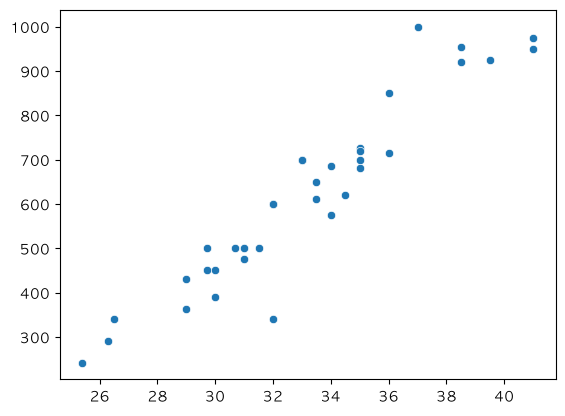

In [130]:
bream_length = list(df[df["Species"] == "Bream"]["Length"])
bream_length

bream_weight = list(df[df["Species"] == "Bream"]["Weight"])
bream_length

print(bream_length)
print(bream_weight)

sns.scatterplot(x=bream_length, y=bream_weight)

[9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
[6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]


<Axes: >

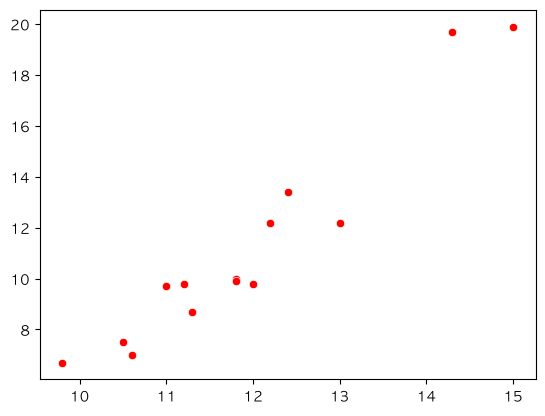

In [131]:
smelt_length = list(df[df["Species"] == "Smelt"]["Length"])
smelt_length

smelt_weight = list(df[df["Species"] == "Smelt"]["Weight"])
smelt_length

print(smelt_length)
print(smelt_weight)

sns.scatterplot(x=smelt_length, y=smelt_weight, color="red")

In [132]:
fish_df = df[df["Species"].isin(["Bream", "Smelt"])]
fish_df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
5,Bream,450.0,29.7,34.7,13.6024,4.9274
6,Bream,500.0,29.7,34.5,14.1795,5.2785
7,Bream,390.0,30.0,35.0,12.6700,4.6900
8,Bream,450.0,30.0,35.1,14.0049,4.8438
9,Bream,500.0,30.7,36.2,14.2266,4.9594


### 분류형 데이터 인코딩

In [133]:
# fish_df["Species"].map(lambda specie : {"Bream" : 0, "Smelt" : 1}[specie])

# 참조형
fish_df["Species"] = fish_df["Species"].map({"Bream" : 0, "Smelt" : 1})
fish_df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,0,242.0,25.4,30.0,11.5200,4.0200
1,0,290.0,26.3,31.2,12.4800,4.3056
2,0,340.0,26.5,31.1,12.3778,4.6961
3,0,363.0,29.0,33.5,12.7300,4.4555
4,0,430.0,29.0,34.0,12.4440,5.1340


## 1단계, 데이터 준비(탐색)

In [134]:
fish_df.info()

<class 'pandas.DataFrame'>
Index: 49 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   49 non-null     int64  
 1   Weight    49 non-null     float64
 2   Length    49 non-null     float64
 3   Diagonal  49 non-null     float64
 4   Height    49 non-null     float64
 5   Width     49 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 2.7 KB


In [135]:
fish_df.describe()

,Species,Weight,Length,Diagonal,Height,Width
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,0.285714,444.500000,27.055102,31.120408,11.476400,4.259751
std,0.456435,328.143233,10.242804,12.097296,6.150976,1.967686
min,0.000000,6.700000,9.800000,10.800000,1.728400,1.047600
25%,0.000000,19.700000,14.300000,15.200000,2.872800,1.879200
50%,0.000000,500.000000,31.000000,36.200000,14.179500,5.072800
75%,1.000000,700.000000,34.500000,39.700000,15.633000,5.589000
max,1.000000,1000.000000,41.000000,46.500000,18.957000,6.749700


In [136]:
fish_df = fish_df.drop(["Diagonal", "Height", "Width"], axis=1)
fish_df

,Species,Weight,Length
0,0,242.0,25.4
1,0,290.0,26.3
2,0,340.0,26.5
3,0,363.0,29.0
4,0,430.0,29.0
5,0,450.0,29.7
6,0,500.0,29.7
7,0,390.0,30.0
8,0,450.0,30.0
9,0,500.0,30.7


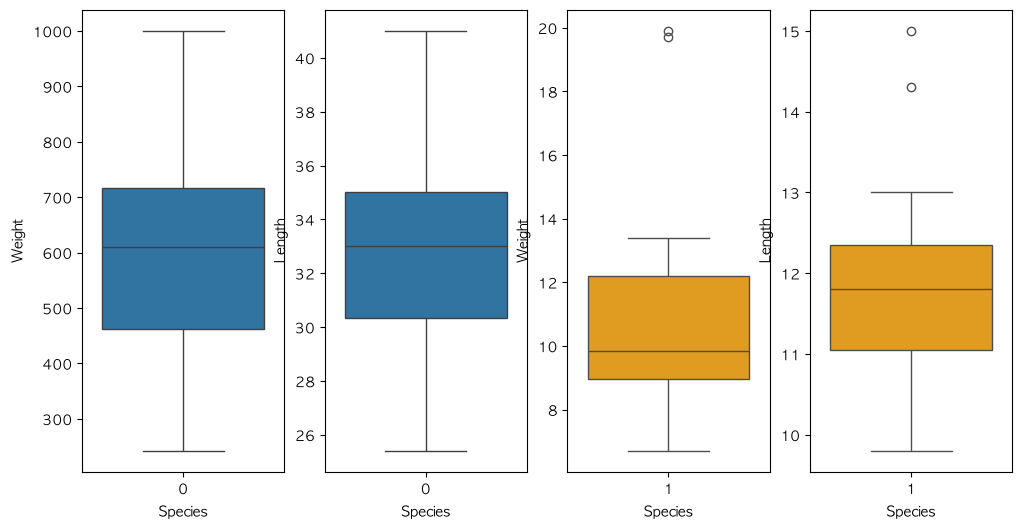

In [137]:
pig, axes = plt.subplots(1, 4, figsize=(12, 6))
sns.boxplot(fish_df[fish_df["Species"] == 0], x="Species", y="Weight", ax=axes[0])
sns.boxplot(fish_df[fish_df["Species"] == 0], x="Species", y="Length", ax=axes[1])
sns.boxplot(fish_df[fish_df["Species"] == 1], x="Species", y="Weight", ax=axes[2], color="orange")
sns.boxplot(fish_df[fish_df["Species"] == 1], x="Species", y="Length", ax=axes[3], color="orange")
plt.show()

## 2단계, 데이터 분할

In [138]:
# 독립 변수 : 영향을 주는 요인(Weight, Length), 종속 변수 : 결과(Species)
X = fish_df.drop("Species", axis=1)
X.head()

,Weight,Length
0,242.0,25.4
1,290.0,26.3
2,340.0,26.5
3,363.0,29.0
4,430.0,29.0


In [139]:
# 독립 변수 : 영향을 주는 요인(Weight, Length), 종속 변수 : 결과(Species)
y = fish_df["Species"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

In [164]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=2026
)

In [165]:
print(X_test.shape, X_train.shape, y_test.shape, y_train.shape)

(10, 2) (39, 2) (10,) (39,)


## 3단계, 모델 준비

## KNN(k- 최근접 이웃, K-Neighbors) 알고리즘
- 어떤 데이터에 대한 답을 구할 때 주변의 다른 데이터를 보고 다수를 차지하는 데이터를 정답으로 결정하는 방식의 알고리즘

## KNN 장점
- 데이터만 있으면 알고리즘을 사용할 수 있다.

## KNN 단점
- 데이터가 많으면 사용하기 힘들며, 많은 메모리를 사용한다.

In [142]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()

## 4단계, 모델 학습

In [143]:
# 표준화가 안된 쓰레기 데이터
kn.fit(X_train, y_train)

KNeighborsClassifier()

## 5단계, 모델 예측

In [144]:
y_pred = kn.predict(X_test)
print(y_pred)
print(list(y_test))

[0 0 1 0 1 1 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0
 1 1]
[0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1]


## 6단계, 모델 평가

In [145]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [146]:
print(f"accuracy_score : {accuracy_score(y_test, y_pred)}")

accuracy_score : 0.9743589743589743


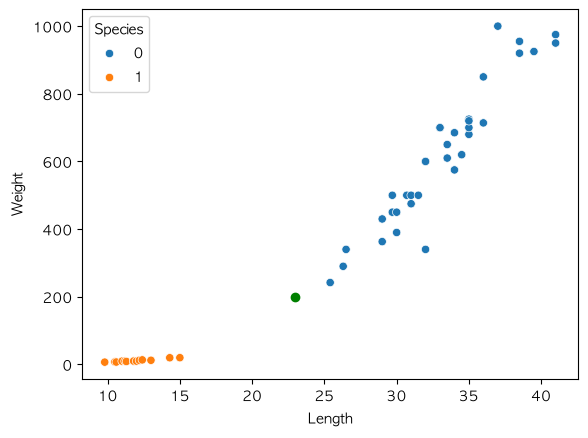

In [147]:
sns.scatterplot(fish_df, x="Length", y="Weight", hue="Species")
plt.scatter(23, 200, color="green")
plt.show()

In [167]:
columns=X_train.columns
new_data = pd.DataFrame([[200, 20]], columns=columns)
new_data

,Weight,Length
0,200,20


In [149]:
kn.predict(new_data)

array([1])

In [150]:
kn.kneighbors(new_data)

(array([[187.96191104, 188.2764988 , 188.46548756, 321.04780018,
         361.41942394]]),
 array([[1, 8, 7, 6, 0]]))

In [151]:
distance, indexes = kn.kneighbors(new_data)
print(distance, indexes)

[[187.96191104 188.2764988  188.46548756 321.04780018 361.41942394]] [[1 8 7 6 0]]


In [152]:
neighbors = X_train.iloc[indexes[0]]
neighbors

,Weight,Length
154,12.2,12.2
153,9.8,12.0
151,10.0,11.8
1,290.0,26.3
13,340.0,32.0


In [153]:
X_train

,Weight,Length
13,340.0,32.0
154,12.2,12.2
20,575.0,34.0
24,700.0,35.0
30,920.0,38.5
26,720.0,35.0
1,290.0,26.3
151,10.0,11.8
153,9.8,12.0
6,500.0,29.7


In [154]:
X_train_scaled

array([[-0.21700535,  0.53080073],
       [-1.26773436, -1.43365804],
       [ 0.53626285,  0.7292309 ],
       [ 0.93693743,  0.82844599],
       [ 1.64212469,  1.1756988 ],
       [ 1.00104536,  0.82844599],
       [-0.37727518, -0.03472528],
       [-1.27478623, -1.47334407],
       [-1.27542731, -1.45350105],
       [ 0.29585811,  0.30260602]])

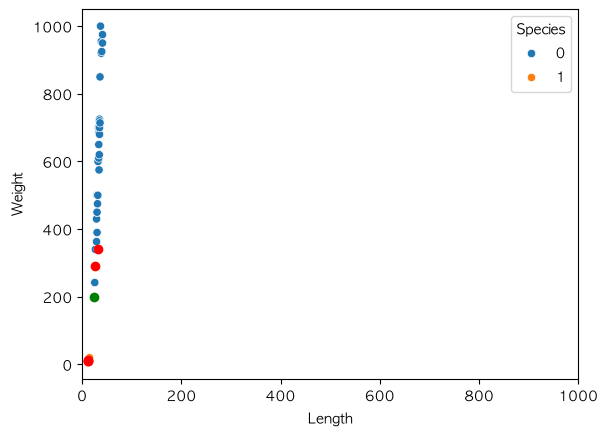

In [155]:
sns.scatterplot(fish_df, x="Length", y="Weight", hue="Species")
plt.scatter(23, 200, color="green")
plt.scatter(neighbors["Length"], neighbors["Weight"], color="red")
plt.xlim(0, 1000)

plt.show()

In [156]:
y_train

13     0
154    1
20     0
24     0
30     0
26     0
1      0
151    1
153    1
6      0
Name: Species, dtype: int64

In [170]:
# StandardScaler 표준화
from sklearn.preprocessing import StandardScaler

# (데이터 값 - 평균) / 표준편차
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [171]:
# (데이터 값 - 평균) / 표준편차
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
print(mean)
print(std)

Weight    453.935897
Length     27.158974
dtype: float64
Weight    327.314297
Length     10.150122
dtype: float64


In [172]:
X_train_scaled_df = (X_train - mean) / std
X_train_scaled_df["Species"] = y_train
X_train_scaled_df.head()

,Weight,Length,Species
32,1.439180,1.215850,0
17,0.751767,0.575464,0
145,-1.366381,-1.710223,1
21,0.705940,0.673985,0
152,-1.356604,-1.513181,1


In [173]:
new_data_scaled = (new_data - mean) / std
new_data_scaled

,Weight,Length
0,-0.775817,-0.705309


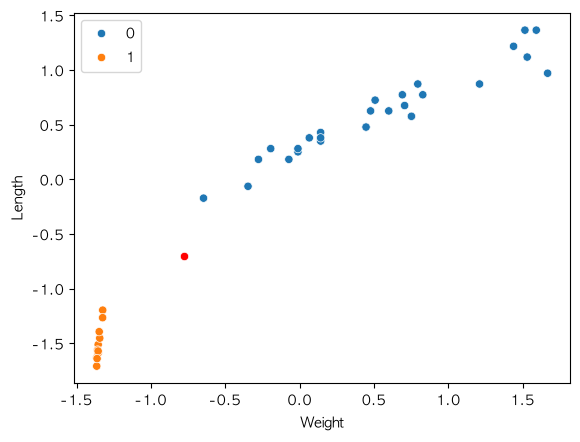

In [174]:
sns.scatterplot(X_train_scaled_df, x="Weight", y="Length", hue="Species")
sns.scatterplot(new_data_scaled, x="Weight", y="Length", color="red")
# plt.scatter(23, 200, color="green")
# plt.scatter(neighbors["Length"], neighbors["Weight"], color="red")
# plt.xlim(0, 1000)

plt.show()

In [179]:
new_data_scaled = (new_data - mean) / std
new_data_scaled

,Weight,Length
0,-0.775817,-0.705309


In [183]:
kn.fit(X_train_scaled, y_train)
y_pred = kn.predict(X_test_scaled)

In [184]:
cm = confusion_matrix(y_test, y_pred)

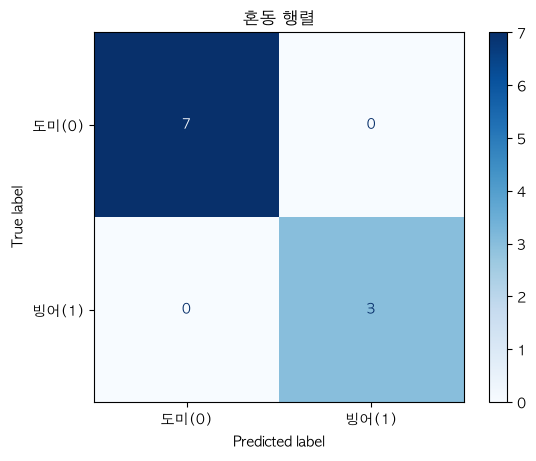

In [185]:
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["도미(0)", "빙어(1)"])
display.plot(cmap="Blues")
plt.title("혼동 행렬")

plt.show()